# Tree Prediction Distributions across Temperature Bins

For the latest EBV model (`rf_gaia_teff_corrected_log_ebv_optuna_20260401_201113`),
sample one random test object per 1000 K bin and visualize:
- Histogram of individual-tree predictions
- Fitted 5-component GMM overlay (total + individual components)
- True temperature value

In [2]:
import sys
sys.path.insert(0, '..')

import joblib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from src.visualization.tree_distributions import (
    plot_tree_distribution_single,
    plot_tree_distributions_grid,
)
from src.visualization.validation_plots import save_figure

%matplotlib inline

## Load model and test predictions

In [3]:
MODEL_ID = "rf_gaia_teff_corrected_log_ebv_optuna_20260417_095531"
MODELS_DIR = Path("../models")

model = joblib.load(MODELS_DIR / f"{MODEL_ID}.pkl")
test_pred = pd.read_parquet(MODELS_DIR / f"{MODEL_ID}_test_predictions.parquet")
with open(MODELS_DIR / f"{MODEL_ID}_metadata.json") as f:
    metadata = json.load(f)

features = metadata["features"]
target_transform = metadata.get("target_transform", "none")

print(f"Model: {MODEL_ID}")
print(f"Trees: {len(model.estimators_)}")
print(f"Features: {features}")
print(f"Target transform: {target_transform}")
print(f"Test samples: {len(test_pred):,}")
print(f"Teff range: {test_pred['y_true'].min():.0f} – {test_pred['y_true'].max():.0f} K")

Model: rf_gaia_teff_corrected_log_ebv_optuna_20260417_095531
Trees: 360
Features: ['g', 'bp', 'rp', 'bp_rp', 'g_bp', 'g_rp', 'ebv_sandf']
Target transform: log
Test samples: 255,234
Teff range: 2833 – 42301 K


## Sample one random object per 1000 K temperature bin

Bins span from 3000 K to the maximum true Teff in 1000 K steps.
We pick one random object from each bin that has at least one member.

In [4]:
BIN_STEP = 1000  # K
teff_min = 3000
teff_max = int(np.ceil(test_pred["y_true"].max() / BIN_STEP) * BIN_STEP)
bin_edges = np.arange(teff_min, teff_max + BIN_STEP, BIN_STEP)

rng = np.random.RandomState(41)
sampled_rows = []
bin_labels = []

for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    mask = (test_pred["y_true"] >= lo) & (test_pred["y_true"] < hi)
    candidates = test_pred[mask]
    if len(candidates) == 0:
        continue
    row = candidates.sample(1, random_state=rng)
    sampled_rows.append(row)
    bin_labels.append(f"{lo/1000:.0f}–{hi/1000:.0f} kK  (n={len(candidates):,})")

sampled = pd.concat(sampled_rows).reset_index(drop=True)
print(f"Selected {len(sampled)} objects from {len(bin_edges)-1} bins")
for i, lbl in enumerate(bin_labels):
    print(f"  {lbl}  →  true Teff = {sampled.loc[i, 'y_true']:.0f} K")

Selected 38 objects from 40 bins
  3–4 kK  (n=26,788)  →  true Teff = 3748 K
  4–5 kK  (n=101,104)  →  true Teff = 4795 K
  5–6 kK  (n=71,533)  →  true Teff = 5733 K
  6–7 kK  (n=22,327)  →  true Teff = 6781 K
  7–8 kK  (n=15,251)  →  true Teff = 7457 K
  8–9 kK  (n=6,873)  →  true Teff = 8331 K
  9–10 kK  (n=7,401)  →  true Teff = 9318 K
  10–11 kK  (n=893)  →  true Teff = 10044 K
  11–12 kK  (n=267)  →  true Teff = 11278 K
  12–13 kK  (n=205)  →  true Teff = 12924 K
  13–14 kK  (n=218)  →  true Teff = 13171 K
  14–15 kK  (n=265)  →  true Teff = 14312 K
  15–16 kK  (n=302)  →  true Teff = 15569 K
  16–17 kK  (n=146)  →  true Teff = 16345 K
  17–18 kK  (n=146)  →  true Teff = 17988 K
  18–19 kK  (n=386)  →  true Teff = 18835 K
  19–20 kK  (n=314)  →  true Teff = 19186 K
  20–21 kK  (n=176)  →  true Teff = 20650 K
  21–22 kK  (n=94)  →  true Teff = 21576 K
  22–23 kK  (n=100)  →  true Teff = 22033 K
  23–24 kK  (n=95)  →  true Teff = 23225 K
  24–25 kK  (n=45)  →  true Teff = 24387 K
  

## Predict with individual trees and collect GMM params

Since the model uses `target_transform: log`, individual tree predictions are in
log10-space. We inverse-transform them to Kelvin before plotting.

In [5]:
X_sampled = sampled[features].values

# Per-tree predictions in log10 space, then inverse-transform to Kelvin
tree_preds_log = np.array([est.predict(X_sampled) for est in model.estimators_])
tree_preds_kelvin = 10 ** tree_preds_log  # (n_trees, n_objects)

# Extract stored GMM parameters
n_comp = 5
gmm_w = sampled[[f"gmm_weight_{k}" for k in range(n_comp)]].values
gmm_m = sampled[[f"gmm_mean_{k}" for k in range(n_comp)]].values
gmm_s = sampled[[f"gmm_sigma_{k}" for k in range(n_comp)]].values

print(f"Tree predictions shape: {tree_preds_kelvin.shape}  (n_trees × n_objects)")
print(f"GMM params shape: weights {gmm_w.shape}, means {gmm_m.shape}, sigmas {gmm_s.shape}")

Tree predictions shape: (360, 38)  (n_trees × n_objects)
GMM params shape: weights (38, 5), means (38, 5), sigmas (38, 5)


## Plot: tree-prediction distributions per temperature bin

   Saved: reports/figures/gaia_teff_corrected_log_ebv_optuna_validation/rf_gaia_teff_corrected_log_ebv_optuna_20260417_095531_tree_distributions.png


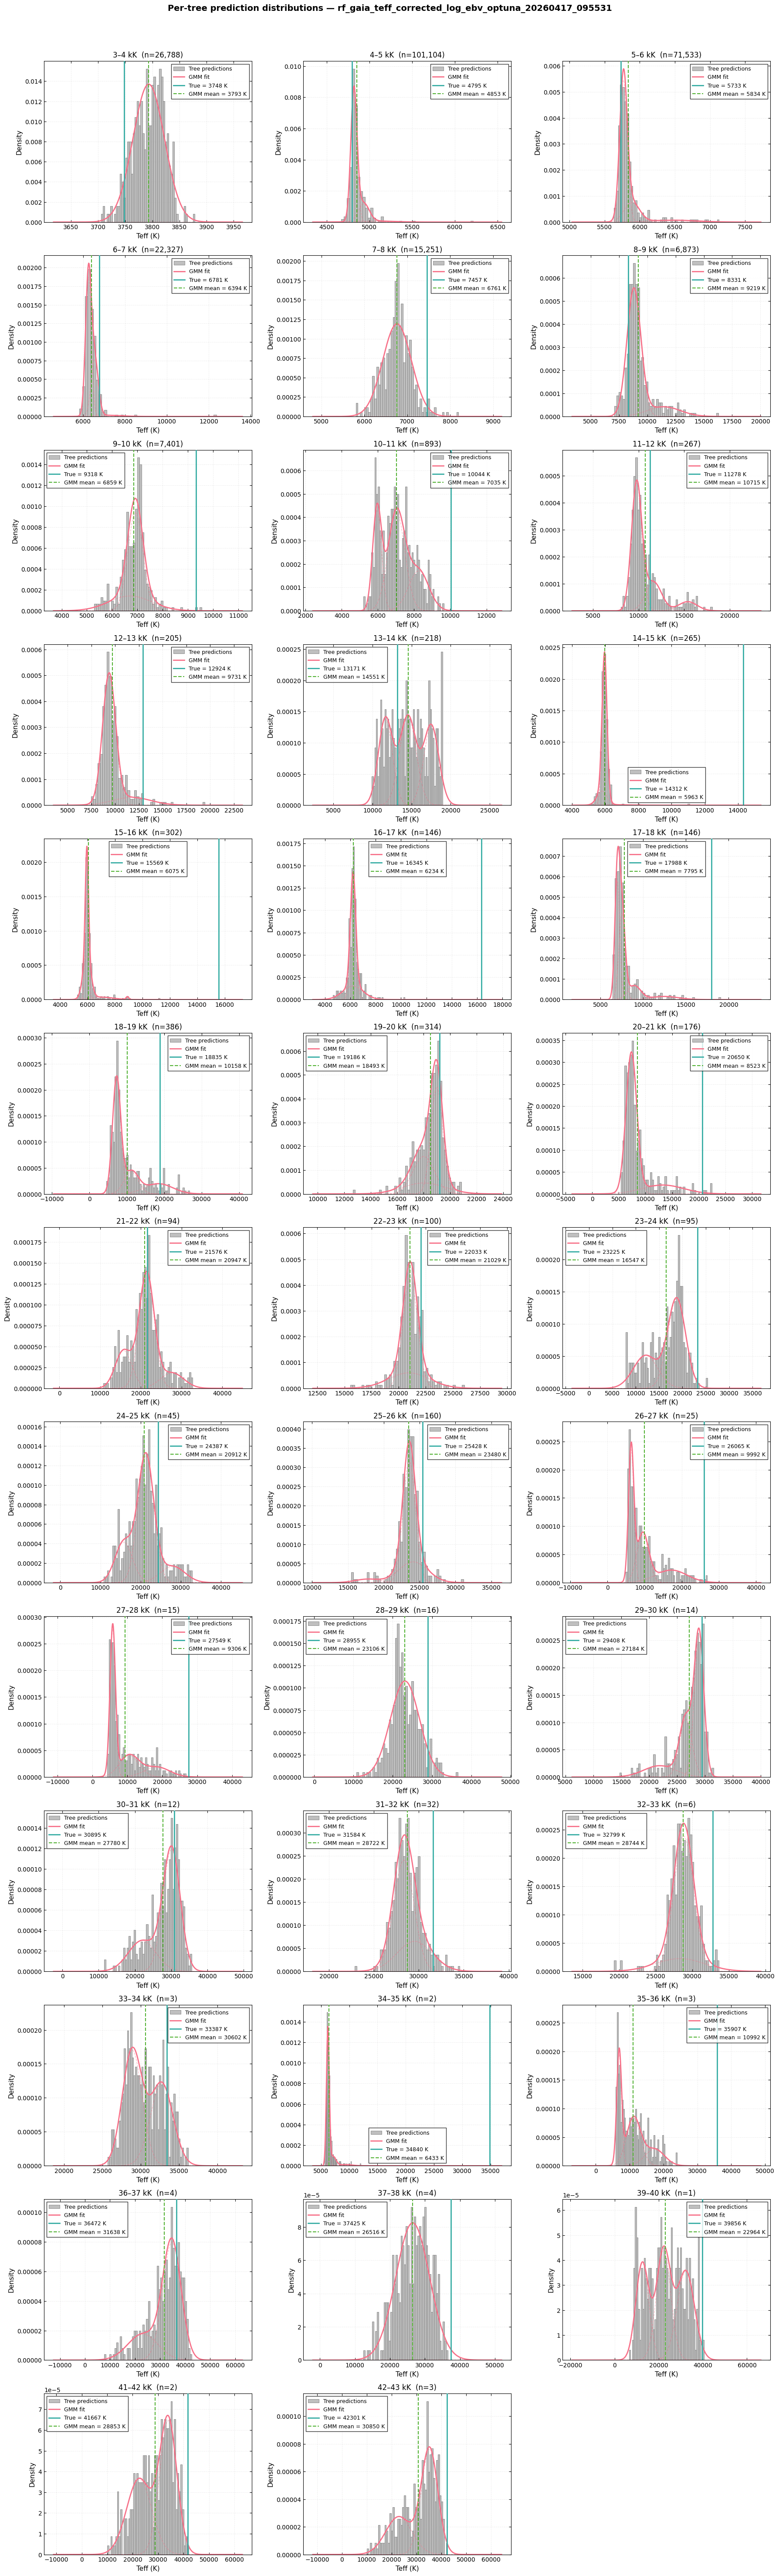

In [6]:
target_info = {"name": "Temperature", "unit": "K", "short": "Teff"}

fig = plot_tree_distributions_grid(
    tree_preds_all=[tree_preds_kelvin[:, i] for i in range(len(sampled))],
    y_true_all=sampled["y_true"].tolist(),
    gmm_weights_all=gmm_w,
    gmm_means_all=gmm_m,
    gmm_sigmas_all=gmm_s,
    bin_labels=bin_labels,
    n_bins=50,
    target_info=target_info,
    suptitle=f"Per-tree prediction distributions — {MODEL_ID}",
    ncols=3,
)

subdir = "gaia_teff_corrected_log_ebv_optuna_validation"
save_figure(fig, f"{MODEL_ID}_tree_distributions.png", subdir)
plt.show()